(-0.5, 959.5, 639.5, -0.5)

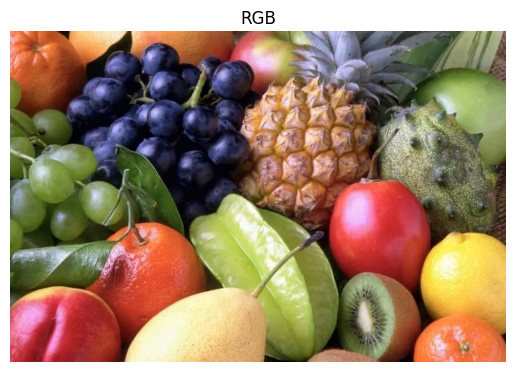

In [7]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os

img_path = rf'photo\fruits.jpg'

img_bgr = cv2.imread(img_path, cv2.IMREAD_COLOR)
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB) 
img_hsv = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2HSV) 

plt.imshow(img_rgb)
plt.title('RGB')
plt.axis('off')


确定葡萄,橙子,柠檬的阈值

In [8]:
# 葡萄
lower_grape = np.array([103, 72, 10])
upper_grape = np.array([125, 255, 250])

# 橙子
lower_orange = np.array([2, 99, 164])
upper_orange = np.array([11, 218, 255])

# 柠檬
lower_lemon = np.array([17, 133, 205]) 
upper_lemon = np.array([28, 206, 255])

#### cv2.inRange
用于从给定的图像中提取特定颜色范围内的像素，创建一个二值掩码（掩膜）图像。

cv2.inRange(src, lower_bound, upper_bound)

#### cv2.findContours
用于从二值图像中检测轮廓

contours, hierarchy = cv2.findContours(image, mode, method)

参数说明

image: 输入图像，必须是二值图像（通常是经过阈值处理或边缘检测后的图像）。

mode: 轮廓检索模式，常用选项包括：

cv2.RETR_EXTERNAL: 只检索最外层轮廓，忽略内部的"洞"

cv2.RETR_LIST: 检索所有轮廓，但不建立层次关系

cv2.RETR_CCOMP: 检索所有轮廓，并将它们组织为两级层次结构

cv2.RETR_TREE: 检索所有轮廓，并重建完整的层次结构

method: 轮廓近似方法：

cv2.CHAIN_APPROX_NONE: 存储所有轮廓点

cv2.CHAIN_APPROX_SIMPLE: 压缩水平、垂直和对角线段，只保留端点（节省内存）



(-0.5, 959.5, 639.5, -0.5)

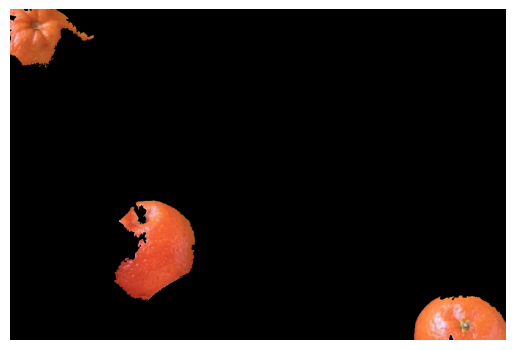

In [9]:
min_orange = 1606

mask = cv2.inRange(img_hsv, lower_orange, upper_orange)

contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

orange_mask = np.zeros_like(mask)
filtered_contours = [c for c in contours if cv2.contourArea(c) > min_orange]
if filtered_contours:
    cv2.drawContours(orange_mask, filtered_contours, -1, (255), thickness=cv2.FILLED)

orange_rgb = cv2.bitwise_and(img_rgb, img_rgb, mask=orange_mask)
plt.imshow(orange_rgb)
plt.axis('off')

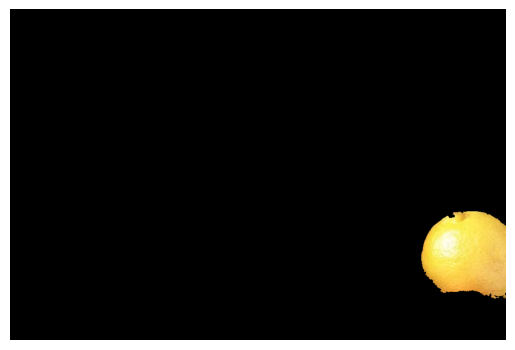

In [10]:
min_lemon = 60

mask_lemon_initial = cv2.inRange(img_hsv, lower_lemon, upper_lemon)

contours_lemon, _ = cv2.findContours(mask_lemon_initial, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

lemon_mask = np.zeros_like(mask_lemon_initial)
filtered_contours_lemon = [c for c in contours_lemon if cv2.contourArea(c) > min_lemon]
if filtered_contours_lemon:
    cv2.drawContours(lemon_mask, filtered_contours_lemon, -1, (255), thickness=cv2.FILLED)

lemon_rgb = cv2.bitwise_and(img_rgb, img_rgb, mask=lemon_mask)

plt.imshow(lemon_rgb)
plt.axis('off')
plt.show()

(-0.5, 959.5, 639.5, -0.5)

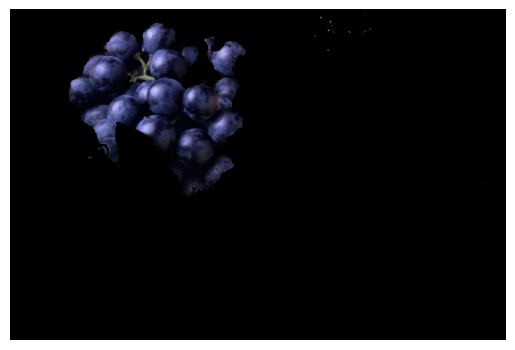

In [11]:
min_grape = 0
mask_grape_initial = cv2.inRange(img_hsv, lower_grape, upper_grape)

contours_grape, _ = cv2.findContours(mask_grape_initial, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

grape_mask = np.zeros_like(mask_grape_initial)
filtered_contours_grape = [c for c in contours_grape if cv2.contourArea(c) > min_grape]
if filtered_contours_grape:
    cv2.drawContours(grape_mask, filtered_contours_grape, -1, (255), thickness=cv2.FILLED)

grape_rgb = cv2.bitwise_and(img_rgb, img_rgb, mask=grape_mask)

plt.imshow(grape_rgb)
plt.axis('off')

(-0.5, 959.5, 639.5, -0.5)

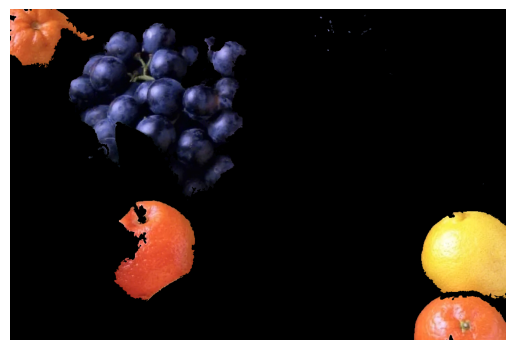

In [12]:
all_rgb = cv2.bitwise_or(orange_rgb, lemon_rgb)
all_rgb = cv2.bitwise_or(all_rgb, grape_rgb)

plt.imshow(all_rgb)
plt.axis('off')